In [1]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

### Understanding the Data

In [2]:
#Importing the data
df = pd.read_csv('transactions.csv')
df.head()

,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,0,1,1,1,2024-01-06T04:09:39Z,370.95,0
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,2024-01-09T20:13:47Z,149.62,0
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,2024-01-12T06:20:11Z,164.08,0
3,4,1,141,47,147.93,112.47,FR,FR,web,fashion,0,1,1,1,2024-01-15T17:00:04Z,397.40,0
4,5,1,141,47,147.93,132.91,FR,US,web,electronics,0,1,1,1,2024-01-17T01:27:31Z,935.28,0


In [3]:
df.columns

Index(['transaction_id', 'user_id', 'account_age_days',
       'total_transactions_user', 'avg_amount_user', 'amount', 'country',
       'bin_country', 'channel', 'merchant_category', 'promo_used',
       'avs_match', 'cvv_result', 'three_ds_flag', 'transaction_time',
       'shipping_distance_km', 'is_fraud'],
      dtype='object')

In [4]:
df.shape

(299695, 17)

In [5]:
df.dtypes

transaction_id               int64
user_id                      int64
account_age_days             int64
total_transactions_user      int64
avg_amount_user            float64
amount                     float64
country                     object
bin_country                 object
channel                     object
merchant_category           object
promo_used                   int64
avs_match                    int64
cvv_result                   int64
three_ds_flag                int64
transaction_time            object
shipping_distance_km       float64
is_fraud                     int64
dtype: object

In [6]:
#Checking missingness
df.isna().sum()

transaction_id             0
user_id                    0
account_age_days           0
total_transactions_user    0
avg_amount_user            0
amount                     0
country                    0
bin_country                0
channel                    0
merchant_category          0
promo_used                 0
avs_match                  0
cvv_result                 0
three_ds_flag              0
transaction_time           0
shipping_distance_km       0
is_fraud                   0
dtype: int64

In [7]:
#Dropping duplicates
df = df.drop_duplicates(keep ='first')

In [8]:
df.shape

(299695, 17)

### Feature Engineering

In [10]:
df.describe()

,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,is_fraud
count,299695.0000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000
mean,149848.0000,3002.559432,973.397871,50.673321,148.142973,177.165279,0.153640,0.837999,0.872110,0.784588,357.049028,0.022062
std,86514.6388,1732.309663,525.241409,5.976391,200.364624,306.926507,0.360603,0.368453,0.333968,0.411109,427.672074,0.146887
min,1.0000,1.000000,1.000000,40.000000,3.520000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,74924.5000,1501.000000,516.000000,46.000000,46.190000,42.100000,0.000000,1.000000,1.000000,1.000000,136.600000,0.000000
50%,149848.0000,3007.000000,975.000000,51.000000,90.130000,89.990000,0.000000,1.000000,1.000000,1.000000,273.020000,0.000000
75%,224771.5000,4504.000000,1425.000000,56.000000,173.450000,191.110000,0.000000,1.000000,1.000000,1.000000,409.180000,0.000000
max,299695.0000,6000.000000,1890.000000,60.000000,4565.290000,16994.740000,1.000000,1.000000,1.000000,1.000000,3748.560000,1.000000


In [11]:
#Creating more features
df['amount_ratio'] = df['amount'] / df['avg_amount_user']

df['country_match'] = (df['country'] == df['bin_country']).astype(int)

df['transaction_time']= pd.to_datetime(df['transaction_time'])
df['hour'] = df['transaction_time'].dt.hour

df['new_account']=(df['account_age_days'] < 30).astype(int)

threshold = df['shipping_distance_km'].quantile(0.75)

df['high_shipping_distance'] = (df['shipping_distance_km'] > threshold).astype(int)

### EDA

In [13]:
df.dtypes

transaction_id                           int64
user_id                                  int64
account_age_days                         int64
total_transactions_user                  int64
avg_amount_user                        float64
amount                                 float64
country                                 object
bin_country                             object
channel                                 object
merchant_category                       object
promo_used                               int64
avs_match                                int64
cvv_result                               int64
three_ds_flag                            int64
transaction_time           datetime64[ns, UTC]
shipping_distance_km                   float64
is_fraud                                 int64
amount_ratio                           float64
country_match                            int64
hour                                     int32
new_account                              int64
high_shipping

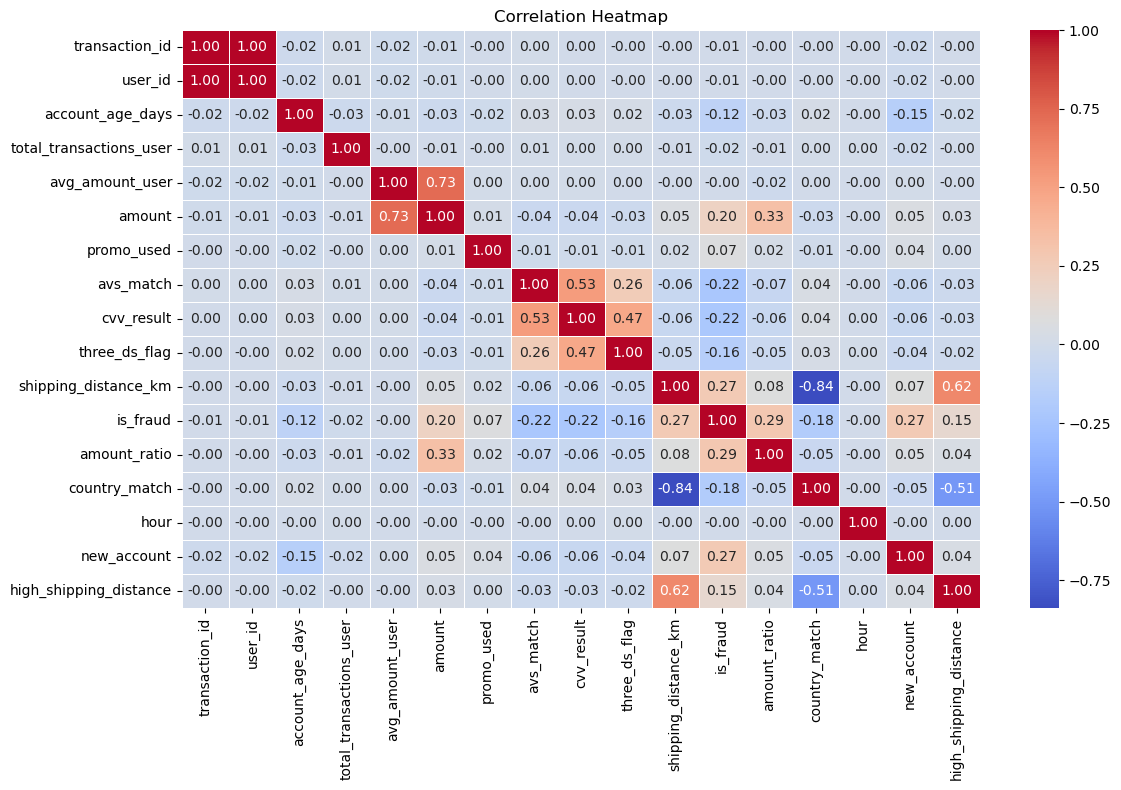

In [14]:
#Heatmap showing correlation of numerical columns
num_cols = df.select_dtypes(include=['int64','int32','float64'])
plt.figure(figsize=(12, 8))
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('fraud_correlation.png')
plt.show()

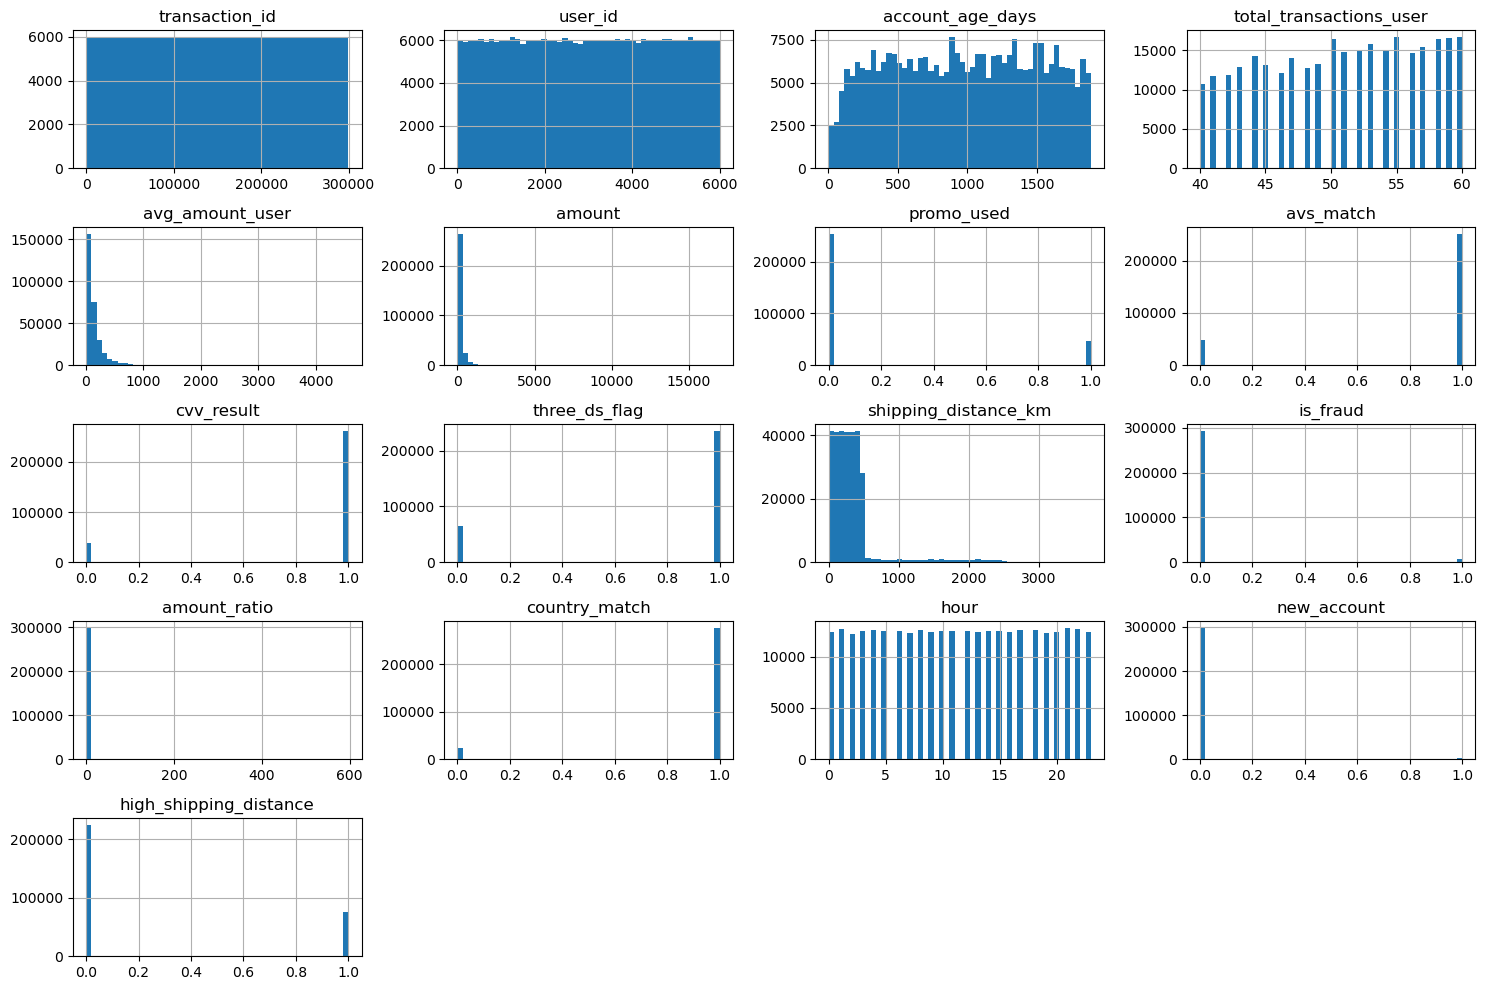

In [15]:
#Histogram showing distribution of numerical columns
num_cols = df.select_dtypes(include=['int64','int32','float64']).columns.to_list()
df[num_cols].hist(figsize=(15, 10),bins=50)
plt.tight_layout()
plt.show()

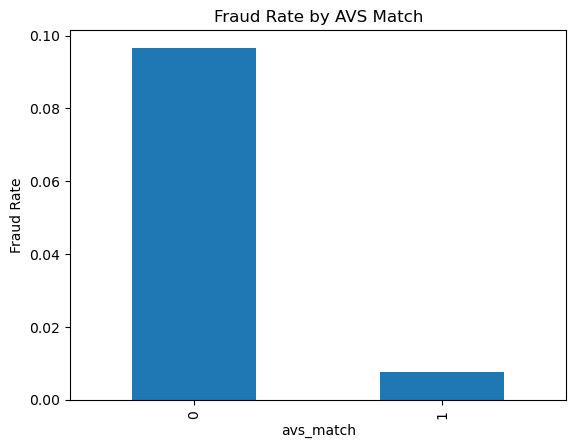

In [16]:
# Fraud rate of features with high correlation
avs_rate = df.groupby('avs_match')['is_fraud'].mean()

avs_rate.plot(kind='bar')
plt.title('Fraud Rate by AVS Match')
plt.ylabel('Fraud Rate')
plt.savefig("avs_match_vs_fraud.png", dpi=300)
plt.show()

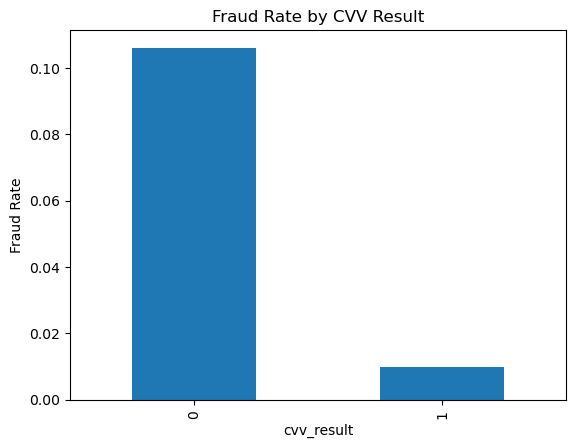

In [17]:
# Fraud rate of features with high correlation
cvv_rate = df.groupby('cvv_result')['is_fraud'].mean()

cvv_rate.plot(kind='bar')
plt.title('Fraud Rate by CVV Result')
plt.ylabel('Fraud Rate')
plt.savefig("cvv_result_vs_fraud.png", dpi=300)
plt.show()

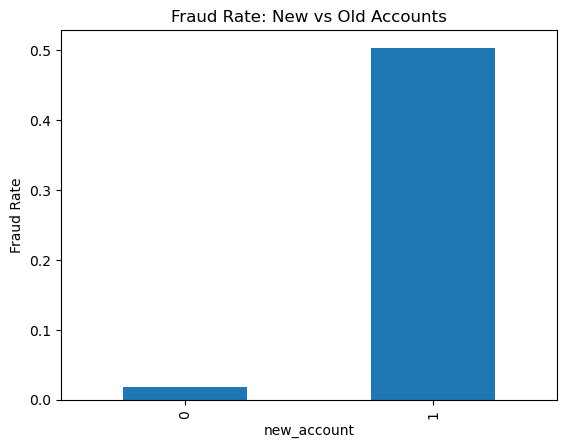

In [18]:
# Fraud rate of features with high correlation
new_acc_rate = df.groupby('new_account')['is_fraud'].mean()

new_acc_rate.plot(kind='bar')
plt.title('Fraud Rate: New vs Old Accounts')
plt.ylabel('Fraud Rate')
plt.savefig("new_account_vs_fraud.png", dpi=300)
plt.show()

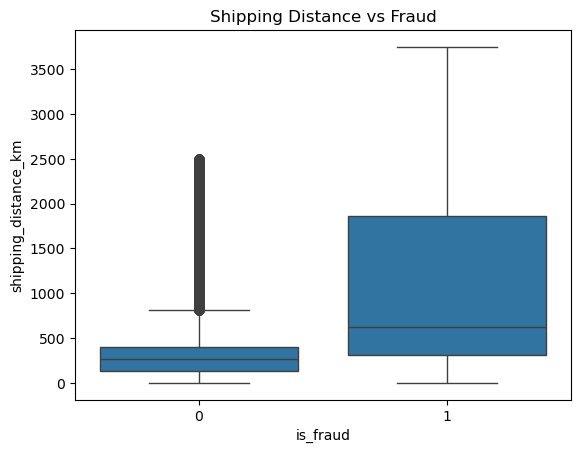

In [19]:
# Fraud rate of features with high correlation
sns.boxplot(x='is_fraud', y='shipping_distance_km', data=df)

plt.title('Shipping Distance vs Fraud')
plt.savefig("shipping_distance_vs_fraud.png", dpi=300)
plt.show()

In [20]:
#Dropping redundant columns
df_model = df.drop(columns=['user_id','transaction_id','transaction_time'])

### Modelling

In [21]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [21]:
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import precision_score, recall_score,f1_score,roc_auc_score

In [22]:
#Classifying target and inpit features and splitting into test and training sets
X = df_model.drop('is_fraud', axis=1)
y = df_model['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [23]:
X_train.dtypes

account_age_days             int64
total_transactions_user      int64
avg_amount_user            float64
amount                     float64
country                     object
bin_country                 object
channel                     object
merchant_category           object
promo_used                   int64
avs_match                    int64
cvv_result                   int64
three_ds_flag                int64
shipping_distance_km       float64
amount_ratio               float64
country_match                int64
hour                         int32
new_account                  int64
high_shipping_distance       int64
dtype: object

In [24]:

num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

In [25]:
#Preprocessor pipeline for data processing
preprocess = ColumnTransformer([('num', StandardScaler(), num_cols),
                                ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [26]:
#Selected base models
log_reg = Pipeline([
    ('prep', preprocess),
    ('model', LogisticRegression(max_iter=1000))
])
linear_svm = Pipeline([
    ('prep', preprocess),
    ('model', LinearSVC(random_state=42,max_iter=5000))
])
rf = Pipeline([
    ('prep', preprocess),
    ('model', RandomForestClassifier(random_state=42))
])
xgb = Pipeline([
    ('prep', preprocess),
    ('model', XGBClassifier(eval_metric='logloss',random_state=42))
])

In [27]:
# Creating a dictionary of the base models and fitting on the training set
base_models=  {'Logistic Regression': log_reg,'linear svm': linear_svm,'Random Forest': rf,'XGBoost': xgb}

for model in base_models.values():
    model.fit(X_train, y_train)

In [28]:
#Base models  with SMOTE Aapplied
log_reg_sm = ImbPipeline([ ('prep', preprocess), ('smote', SMOTE(random_state=42)), ('model', LogisticRegression(max_iter=1000))])

svm_sm = ImbPipeline([('prep', preprocess),('smote', SMOTE(random_state=42)),('model', LinearSVC(random_state=42,max_iter=5000))])

rf_sm = ImbPipeline([('prep', preprocess),('smote', SMOTE(random_state=42)),('model', RandomForestClassifier(random_state=42))])

xgb_sm = ImbPipeline([('prep', preprocess),('smote', SMOTE(random_state=42)),('model', XGBClassifier(eval_metric='logloss',random_state=42))])

In [29]:
#Fitting SMOTE models on training set
models_sm = {'Logistic Regression_sm': log_reg_sm,'SVM_sm': svm_sm,'Random Forest_sm': rf_sm,'XGBoost_sm': xgb_sm}

for model in models_sm.values():
    model.fit(X_train, y_train)

In [30]:
#Predicting and evaluating model according to selected metrics
def evaluate_model(name, model, X_test, y_test):

    y_pred = model.predict(X_test)

    if hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        y_score = model.predict_proba(X_test)[:, 1]

    return {
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_score)
    }

In [31]:
# Dictionary containing the base models and SMOTE models
results = []

for name, model in base_models.items():
    results.append(
        evaluate_model(name, model,X_test,y_test)
    )

for name, model in models_sm.items():
    results.append(
        evaluate_model(name, model,X_test,y_test)
    )

In [32]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values( by='ROC_AUC', ascending=False)
results_df

,Model,Precision,Recall,F1,ROC_AUC
3,XGBoost,0.917197,0.762481,0.832714,0.972985
7,XGBoost_sm,0.902482,0.770045,0.831020,0.972463
6,Random Forest_sm,0.826156,0.783661,0.804348,0.965553
2,Random Forest,0.946277,0.759455,0.842635,0.960468
5,SVM_sm,0.167680,0.855522,0.280402,0.945863
0,Logistic Regression,0.860294,0.442511,0.584416,0.945742
4,Logistic Regression_sm,0.167796,0.861573,0.280888,0.945734
1,linear svm,0.952569,0.364599,0.527352,0.942127


### Hyperparameter tuning

In [ ]:
#Hyperparameter tuning of best base model
xgb = Pipeline([('prep', preprocess),
                ('model', XGBClassifier(eval_metric='logloss',random_state=42,n_jobs=-1))
])
param_xgb = {
    'model__n_estimators': [200, 400, 600],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.9, 1]
}
xgb_search = RandomizedSearchCV(xgb,param_xgb,n_iter=15,scoring='roc_auc',cv=3,n_jobs=-1,random_state=42,)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_

In [ ]:
#Hyperparameter tuning of best SMOTE model
xgb_sm = ImbPipeline([
    ('prep', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(eval_metric='logloss',random_state=42,n_jobs=-1))
])
param_xgb = {
    'model__n_estimators': [200, 400, 600],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.9, 1]
}
xgb_search_sm = RandomizedSearchCV(xgb,param_xgb,n_iter=15,scoring='roc_auc',cv=3,n_jobs=-1,random_state=42,)

xgb_search_sm.fit(X_train, y_train)

best_xgb_sm = xgb_search_sm.best_estimator_

In [ ]:
results_tuned = []

results_tuned.append(
    evaluate_model("XGBoost_Tuned", best_xgb, X_test, y_test)
)

results_tuned.append(
    evaluate_model("XGBoost_SMOTE_Tuned", best_xgb_sm, X_test, y_test)
)

In [ ]:
results_tuned = pd.DataFrame(results_tuned)
results_tuned.sort_values(by="ROC_AUC", ascending=False)

### Feature Importances

In [ ]:
# Extract trained XGBoost model
xgb_model = best_xgb.named_steps['model']

# Get feature names after preprocessing
feature_names = best_xgb.named_steps['prep'].get_feature_names_out()

# Create importance dataframe
xgb_importance = pd.DataFrame({'feature': feature_names,'importance': xgb_model.feature_importances_})

xgb_importance = xgb_importance.sort_values( by='importance', ascending=False)
